In [86]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler

# Reading FITS files

In [3]:
DR16 = fits.open("DR16Q_v4.fits")   #original
Shen = fits.open("DR16Q_Shen.fits") #Shen w/ BH masses

In [4]:
data = DR16[1].data
data2 = Shen[1].data

print(data2.shape)


(750414,)


# Plots

Text(0.5, 1.0, 'Redshift')

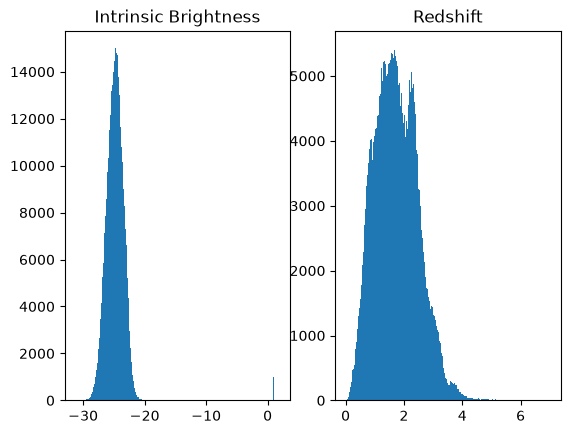

In [5]:
MIgood = data.M_I != -999
Zgood = data.Z != -999

fig,axes = plt.subplots(1,2)
axes[0].hist(data.M_I[MIgood], bins = 500)
axes[0].set_title('Intrinsic Brightness')

axes[1].hist(data.Z[Zgood], bins = 500)
axes[1].set_title('Redshift')

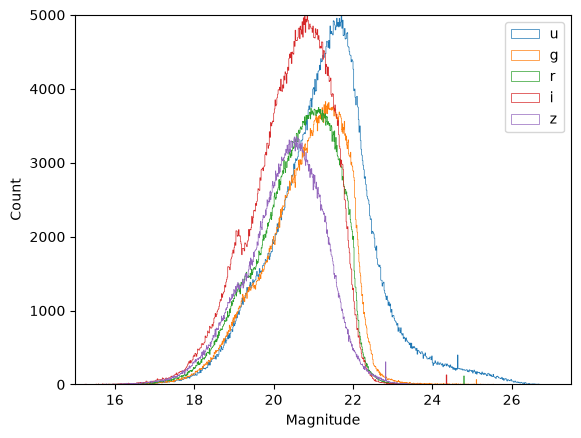

In [6]:
u_mag = data.PSFMAG[:, 0]
g_mag = data.PSFMAG[:, 1]
r_mag = data.PSFMAG[:, 2]
i_mag = data.PSFMAG[:, 3]
z_mag = data.PSFMAG[:, 4]

ug = data.PSFMAG[:, 0] != -9999
gg = data.PSFMAG[:, 1] != -9999
rg = data.PSFMAG[:, 2] != -9999
ig = data.PSFMAG[:, 3] != -9999
zg = data.PSFMAG[:, 4] != -9999

plt.hist(u_mag[ug],bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(g_mag[gg],bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(r_mag[rg],bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(i_mag[ig],bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(z_mag[zg],bins = 1000, linewidth = 0.5, histtype='step')
plt.legend(['u','g','r','i','z'])
plt.axis([15, 27.5, 0, 5000])
plt.ylabel('Count')
plt.xlabel('Magnitude')
plt.show()

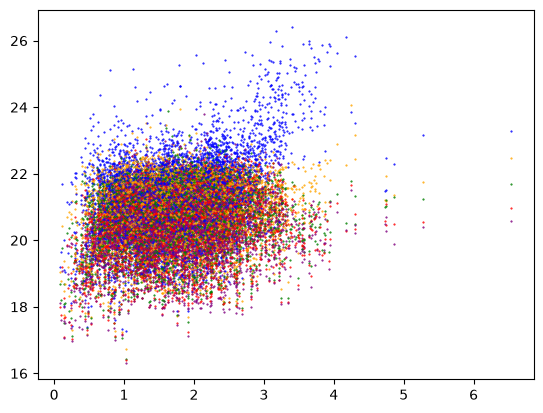

In [7]:
#for i in range(len(data.Z)):
for i in range(5000):
    if data.Z[i] != -999 and u_mag[i] != -9999 and g_mag[i] != -9999 and r_mag[i] != -9999 and i_mag[i] != -9999 and z_mag[i] != -9999:
        plt.plot(data.Z[i], u_mag[i],markersize = 1, marker=".", color="blue")  
        plt.plot(data.Z[i], g_mag[i],markersize = 1, marker=".", color="orange")
        plt.plot(data.Z[i], r_mag[i],markersize = 1, marker=".", color="green")
        plt.plot(data.Z[i], i_mag[i],markersize = 1, marker=".", color="red")
        plt.plot(data.Z[i], z_mag[i],markersize = 1, marker=".", color="purple")
    else:
        continue
    

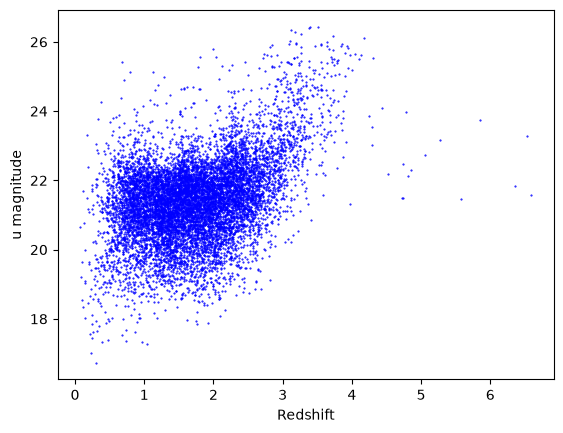

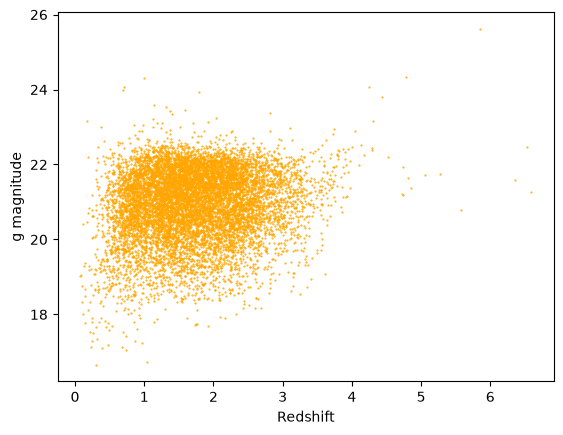

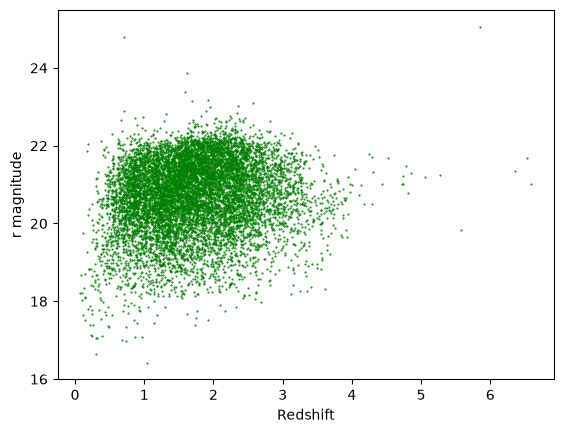

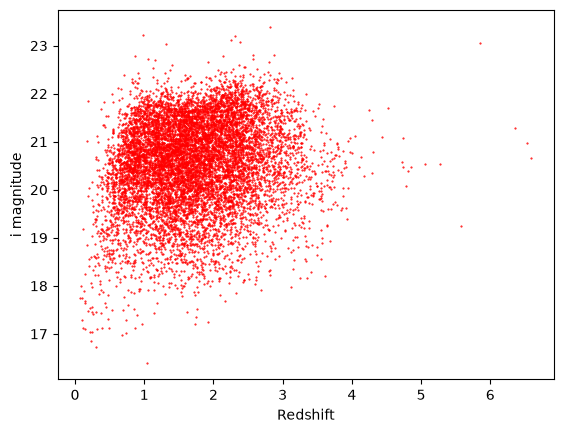

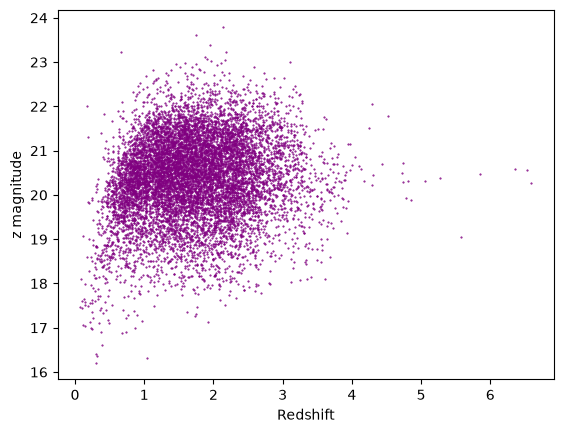

In [8]:
plt.figure()
for i in range(10000):
    if data.Z[i] != -999 and u_mag[i] != -9999:
        plt.plot(data.Z[i], u_mag[i], markersize=1, marker=".", color="blue")
plt.xlabel("Redshift")
plt.ylabel("u magnitude")
plt.show()

plt.figure()
for i in range(10000):
    if data.Z[i] != -999 and g_mag[i] != -9999:
        plt.plot(data.Z[i], g_mag[i], markersize=1, marker=".", color="orange")
plt.xlabel("Redshift")
plt.ylabel("g magnitude")
plt.show()

plt.figure()
for i in range(10000):
    if data.Z[i] != -999 and r_mag[i] != -9999:
        plt.plot(data.Z[i], r_mag[i], markersize=1, marker=".", color="green")
plt.xlabel("Redshift")
plt.ylabel("r magnitude")
plt.show()

plt.figure()
for i in range(10000):
    if data.Z[i] != -999 and i_mag[i] != -9999:
        plt.plot(data.Z[i], i_mag[i], markersize=1, marker=".", color="red")
plt.xlabel("Redshift")
plt.ylabel("i magnitude")
plt.show()

plt.figure()
for i in range(10000):
    if data.Z[i] != -999 and z_mag[i] != -9999:
        plt.plot(data.Z[i], z_mag[i], markersize=1, marker=".", color="purple")
plt.xlabel("Redshift")
plt.ylabel("z magnitude")
plt.show()

Text(0, 0.5, 'Count')

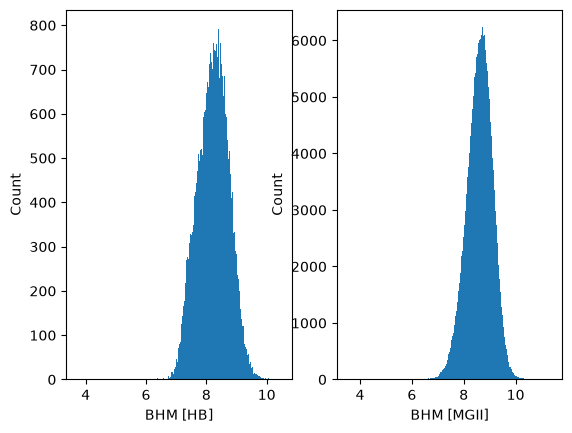

In [9]:
BH_HBgood = data2.LOGMBH_HB != 0
BH_MGIIgood = data2.LOGMBH_MGII != 0

fig, axis = plt.subplots(1,2)

axis[0].hist(data2.LOGMBH_HB[BH_HBgood], bins = 500)
axis[0].set_xlabel('BHM [HB]')
axis[0].set_ylabel('Count')

axis[1].hist(data2.LOGMBH_MGII[BH_MGIIgood], bins = 500)
axis[1].set_xlabel('BHM [MGII]')
axis[1].set_ylabel('Count')

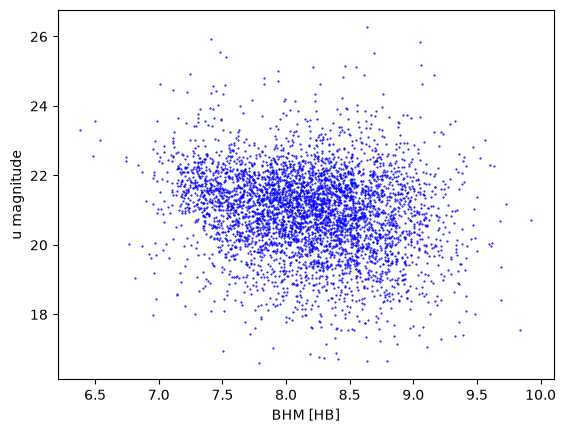

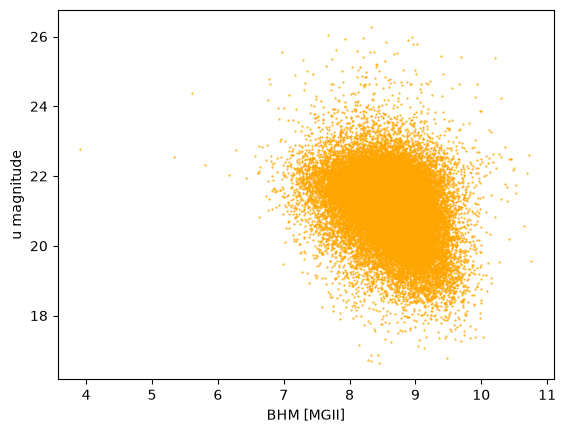

In [10]:
plt.figure()
for i in range(50000):
    if data2.LOGMBH_HB[i] != 0 and u_mag[i] != -9999:
        plt.plot(data2.LOGMBH_HB[i], u_mag[i], markersize=1, marker=".", color="blue")
plt.xlabel("BHM [HB]")
plt.ylabel("u magnitude")
plt.show()

plt.figure()
for i in range(50000):
    if data2.LOGMBH_MGII[i] != 0 and u_mag[i] != -9999:
        plt.plot(data2.LOGMBH_MGII[i], u_mag[i], markersize=1, marker=".", color="orange")
plt.xlabel("BHM [MGII]")
plt.ylabel("u magnitude")
plt.show()


In [13]:
X = np.column_stack([data2.LOGMBH_MGII[:50000], u_mag[:50000]])

good = ((X[:, 0] != 0) & (X[:, 1] != -9999))

X = X[good] 

X = StandardScaler().fit_transform(X)

#labels = DBSCAN(eps=0.3, min_samples=10).fit_predict(X)
db = DBSCAN(eps=0.3, min_samples=10)
labels = db.fit_predict(X)

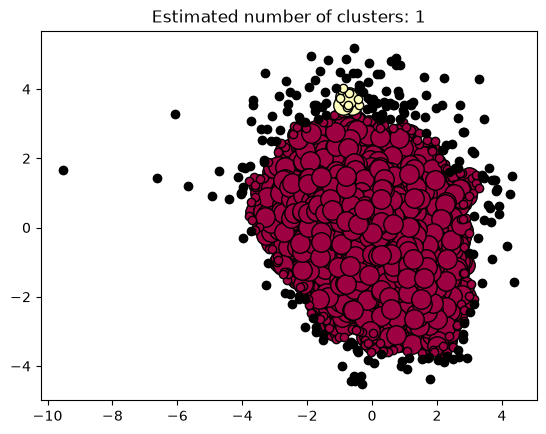

In [14]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=14)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=6)

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

Clusters: 2
Noise points: 2949


Text(0, 0.5, 'u magnitude')

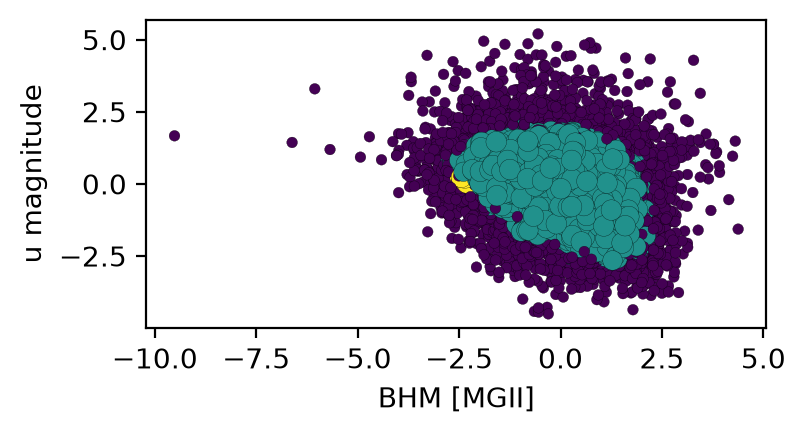

In [100]:
#define the inputs and scale
Y = np.column_stack([data2.LOGMBH_MGII[:50000], u_mag[:50000]])
valid = ((Y[:,0] != 0) & (Y[:,1] != -9999))
Y = Y[valid]
Y_scaled = StandardScaler(copy = True).fit_transform(Y)

#initiate dbscan
# db = DBSCAN(eps = 0.3,min_samples = 10)
# labels = db.fit_predict(Y_scaled)

#initiate HDBSCAN
db = HDBSCAN(min_cluster_size=30, min_samples=10, copy = True)
labels = db.fit_predict(Y_scaled)

#count clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = labels == -1

print("Clusters:", n_clusters)
print("Noise points:", np.sum(noise))

#define sizes
#DBSCAN
# mask = np.zeros_like(labels, dtype = bool) 
# mask[db.core_sample_indices_] = True 
# sizes = np.where(mask, 40, 15)
#HDBSCAN
sizes = 15 + 40 * db.probabilities_

#plot
plt.figure(figsize=(4, 2), dpi=200)

plt.scatter(Y_scaled[:,0],Y_scaled[:,1],c = labels, s = sizes, edgecolor = 'black', linewidth = 0.1)
plt.xlabel("BHM [MGII]")
plt.ylabel("u magnitude")


# Outlier Detection method notes
Three methods of detection exist to classify outliers and normal points

## Supervised:
A supervised detection method is one in which a normal classification is defined by an individual, that class is then used to compare other points, if they do not fit the description they are labeled outliers. One can make several classes however this method struggles with inbalance. Most data will have very few outliers in comparison to the normal points. This leaves our classifyer with very little information to learn about outliers. A couple ways to mitigate this are through oversampling or creating artificial outliers.

## Unsupervised:
An unsupervised detection method works with clusters. Data point may make more than one cluster which we can consider to be normal. Any points that are far isolated from a group can then be considered an outlier. This is the kind of method DBSCAN is. The weaknesses of this method is many of these points could be noise instead of actual outliers. Also it is energy intensive due to having to identify all the normal points before you can get to the outliers which is what we care about, having to process seemingly unimportant information is anapealing because its computationally expensive.

## Semi_Supervised
Semi_supervised detection is a combination of the two, again it struggles with low outlier availibility
